# Numba Benchmark: O(N^x), x=1..5

- `N` をデータ数の基準値として使います。
- 各 `x` に対してデータ長を `M = N^x` に設定します。
- 配列を1回だけ走査するループ計算を行うため、計算量は `O(M) = O(N^x)` です。
- 同じ計算を `Pure Python` と `Numba` で比較します。

In [18]:
import time
import statistics
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import numba
from numba import njit

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 17
mpl.rcParams['axes.labelsize'] = 19
mpl.rcParams['axes.titlesize'] = 20
mpl.rcParams['xtick.labelsize'] = 17
mpl.rcParams['ytick.labelsize'] = 17
mpl.rcParams['legend.fontsize'] = 17

print('NumPy :', np.__version__)
print('Numba :', numba.__version__)

NumPy : 2.2.6
Numba : 0.64.0


In [ ]:
def work_python(a: np.ndarray) -> float:
    acc = 0.0
    for i in range(a.size):
        v = a[i]
        acc += (v * v + 0.5 * v + 1.0) / (v + 1.0)
    return acc


@njit(cache=True)
def work_numba(a: np.ndarray) -> float:
    acc = 0.0
    for i in range(a.size):
        v = a[i]
        acc += (v * v + 0.5 * v + 1.0) / (v + 1.0)
    return acc


def timed_ms(fn, *args):
    t0 = time.perf_counter()
    out = fn(*args)
    return (time.perf_counter() - t0) * 1000.0, out

In [19]:
# N はデータ数の基準値
N = 10
x_values = [1, 2, 3, 4, 5]
sizes = [N ** x for x in x_values]

repeats = 3
seed = 42
rng = np.random.default_rng(seed)

# Numba first compile timing
warm = rng.random(sizes[0], dtype=np.float64)
compile_ms, _ = timed_ms(work_numba, warm)
print(f'Numba first-call compile time: {compile_ms:.3f} ms')

python_ms = []
numba_ms = []
speedups = []

print('\\nx   size=N^x      Python(ms)   Numba(ms)    Speedup')
print('-' * 54)
for x, size in zip(x_values, sizes):
    a = rng.random(size, dtype=np.float64)

    # correctness check (same formula)
    py_val = work_python(a)
    nb_val = work_numba(a)
    rel_err = abs(py_val - nb_val) / (abs(py_val) + 1e-12)

    py_times = [timed_ms(work_python, a)[0] for _ in range(repeats)]
    nb_times = [timed_ms(work_numba, a)[0] for _ in range(repeats)]

    py_avg = statistics.mean(py_times)
    nb_avg = statistics.mean(nb_times)

    python_ms.append(py_avg)
    numba_ms.append(nb_avg)
    speedups.append(py_avg / nb_avg)

    print(f'{x:>1}   {size:>8}   {py_avg:>11.3f}   {nb_avg:>9.3f}   {py_avg / nb_avg:>7.2f}x   err={rel_err:.2e}')

Numba first-call compile time: 0.012 ms
\nx   size=N^x      Python(ms)   Numba(ms)    Speedup
------------------------------------------------------
1         10         0.015       0.001     10.23x   err=0.00e+00
2        100         0.122       0.002     69.23x   err=0.00e+00
3       1000         0.818       0.004    188.77x   err=0.00e+00
4      10000        11.449       0.046    249.80x   err=0.00e+00
5     100000        86.340       0.254    339.39x   err=0.00e+00


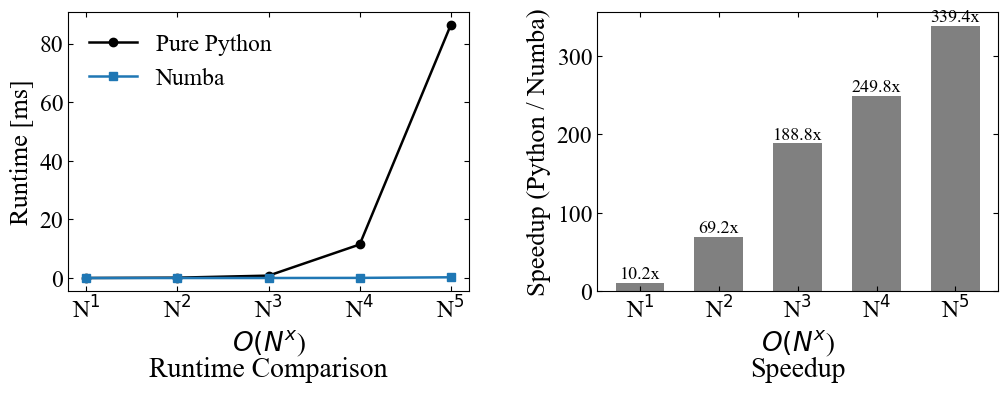

In [22]:
labels = [rf'N$^{{{x}}}$' for x in x_values]
x_pos = np.arange(len(x_values))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].plot(x_pos, python_ms, marker='o', linewidth=1.8, color='black', label='Pure Python')
axes[0].plot(x_pos, numba_ms, marker='s', linewidth=1.8, color='tab:blue', label='Numba')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(labels)
axes[0].set_xlabel('$O(N^x$)')
axes[0].set_ylabel('Runtime [ms]')
axes[0].legend(frameon=False)
axes[0].set_title('Runtime Comparison', y=-0.34)

bars = axes[1].bar(x_pos, speedups, width=0.62, color='gray')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels)
axes[1].set_xlabel('$O(N^x$)')
axes[1].set_ylabel('Speedup (Python / Numba)')
axes[1].set_title('Speedup', y=-0.34)

for bar, v in zip(bars, speedups):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v, f'{v:.1f}x', ha='center', va='bottom', fontsize=13)

for ax in axes:
    ax.grid(False)
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

fig.subplots_adjust(bottom=0.30, wspace=0.32)
plt.show()